# Tesla Stock Price Time Series Analysis

## Introduction
This project analyses Tesla stock prices from 1 January 2015 to 1 January 2026 using time series analysis techniques. The aim is to explore historical behaviour in Tesla's closing stock price, test for stationarity, apply forecasting models and evaluate their performance.

The main variable of interest is the closing price as it reflects the final value of Tesla stock at the end of each trading day.

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_error

import yfinance as yf

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.gofplots import qqplot
from statsmodels.tsa.seasonal import STL, seasonal_decompose

data = yf.download("TSLA", start="2015-01-01", end="2026-01-01")

data.to_csv(r"C:\Users\killi\OneDrive - Dundalk Institute of Technology\tesla-time-series-analysis\data\tesla_stock_data.csv")

data.index = pd.to_datetime(data.index)

close = data["Close"].copy()
close.index = pd.to_datetime(close.index)

close_b = close.asfreq("B").ffill()

print("Original observations:", close.shape[0])
print("Business-day grid observations:", close_b.shape[0])
print("Missing values after asfreq('B') and ffill:", close_b.isna().sum())

print("Duplicate timestamps:", close.index.duplicated().sum())

[*********************100%***********************]  1 of 1 completed

Original observations: 2766
Business-day grid observations: 2869
Missing values after asfreq('B') and ffill: Ticker
TSLA    0
dtype: int64
Duplicate timestamps: 0


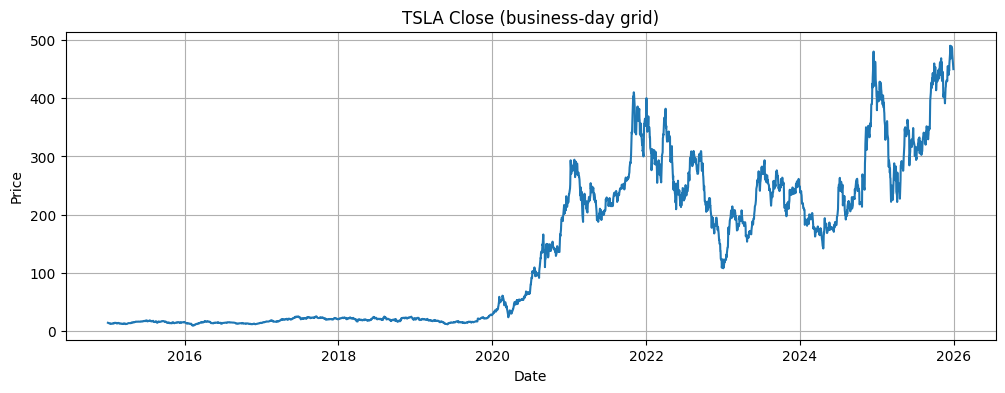

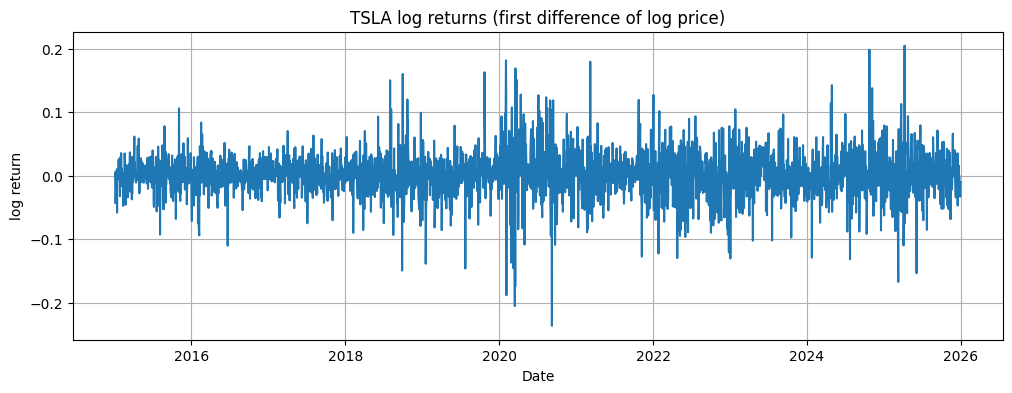

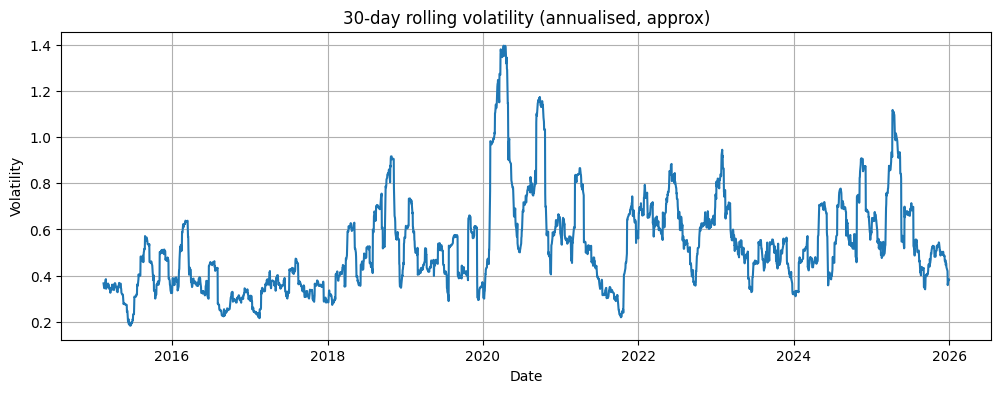

In [14]:
# Helpful transformations for EDA
log_close = np.log(close_b)
log_returns = log_close.diff().dropna()  # approx daily log returns

plt.figure(figsize=(12, 4))
plt.plot(close_b.index, close_b)
plt.title("TSLA Close (business-day grid)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(log_returns.index, log_returns)
plt.title("TSLA log returns (first difference of log price)")
plt.xlabel("Date")
plt.ylabel("log return")
plt.grid(True)
plt.show()

# Rolling volatility (approx 252 trading days)
rolling_vol = log_returns.rolling(30).std() * np.sqrt(252)

plt.figure(figsize=(12, 4))
plt.plot(rolling_vol.index, rolling_vol)
plt.title("30-day rolling volatility (annualised, approx)")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.grid(True)
plt.show()